# Part III: Text Classification using RNN, LSTM and GloVe
## 6CS012 - Sarcasm Detection in News Headlines

**Student:** Sandhya Shiwakoti  
**Module:** Artificial Intelligence and Machine Learning (6CS012)  
**Institution:** Herald College Kathmandu - University of Wolverhampton  


## Setup: Install Libraries and Mount Drive

In [ ]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install libraries not available by default in colab
!pip install contractions wordcloud gensim gradio --quiet

In [ ]:
# Import all libraries needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
import time
from collections import Counter

import contractions
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

import gensim.downloader as api

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Bidirectional,
    Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("All libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully.
TensorFlow version: 2.20.0


## Section 1: Load and Explore the Dataset

In [ ]:
# Load dataset from google drive
DATASET_PATH = '/content/drive/MyDrive/AI_ML_Assessment/sarcastic_headlines.csv'
df = pd.read_csv(DATASET_PATH)

# Keep only relevant columns
df = df[['headline', 'is_sarcastic']]

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (28619, 2)

First 5 rows:


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


In [ ]:
# Check dataset info and missing values
print("Column names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nClass distribution:")
print(df['is_sarcastic'].value_counts())

Column names: ['headline', 'is_sarcastic']

Data types:
headline        object
is_sarcastic     int64
dtype: object

Missing values:
headline        0
is_sarcastic    0
dtype: int64

Class distribution:
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64


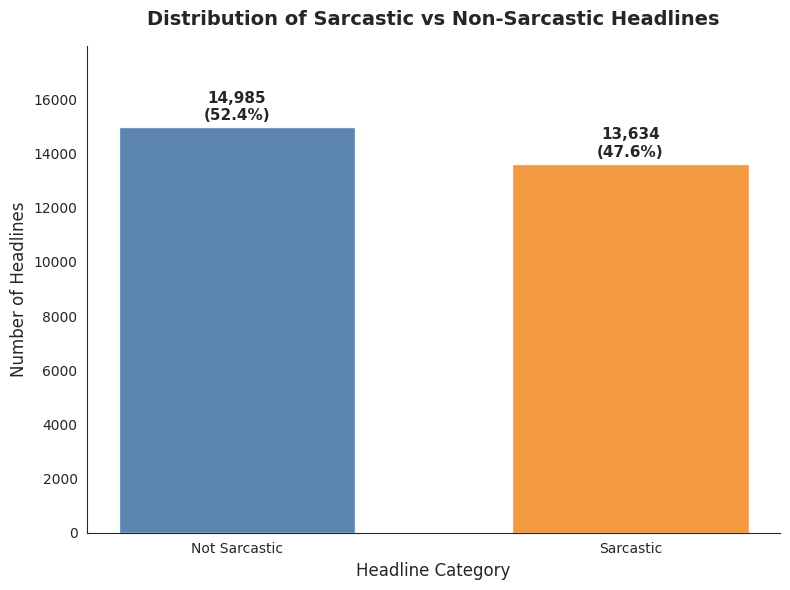

Total    : 28619
Sarcastic    : 13634 (47.6%)
Not Sarcastic: 14985  (52.4%)


In [ ]:
# Plot class distribution bar chart
total     = len(df)
sarcastic = int(df['is_sarcastic'].sum())
not_sarc  = total - sarcastic

plt.figure(figsize=(8, 6))
sns.set_style("white")

colors = ['#4A79A7', '#F28E2B']
bars   = plt.bar(['Not Sarcastic', 'Sarcastic'],
                 [not_sarc, sarcastic],
                 color=colors, width=0.6, alpha=0.9)

for bar, count in zip(bars, [not_sarc, sarcastic]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 150,
             f'{count:,}\n({count/total*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Distribution of Sarcastic vs Non-Sarcastic Headlines',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Number of Headlines', fontsize=12)
plt.xlabel('Headline Category', fontsize=12)
plt.ylim(0, max(not_sarc, sarcastic) * 1.2)
sns.despine()
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

print(f"Total    : {total}")
print(f"Sarcastic    : {sarcastic} ({sarcastic/total*100:.1f}%)")
print(f"Not Sarcastic: {not_sarc}  ({not_sarc/total*100:.1f}%)")

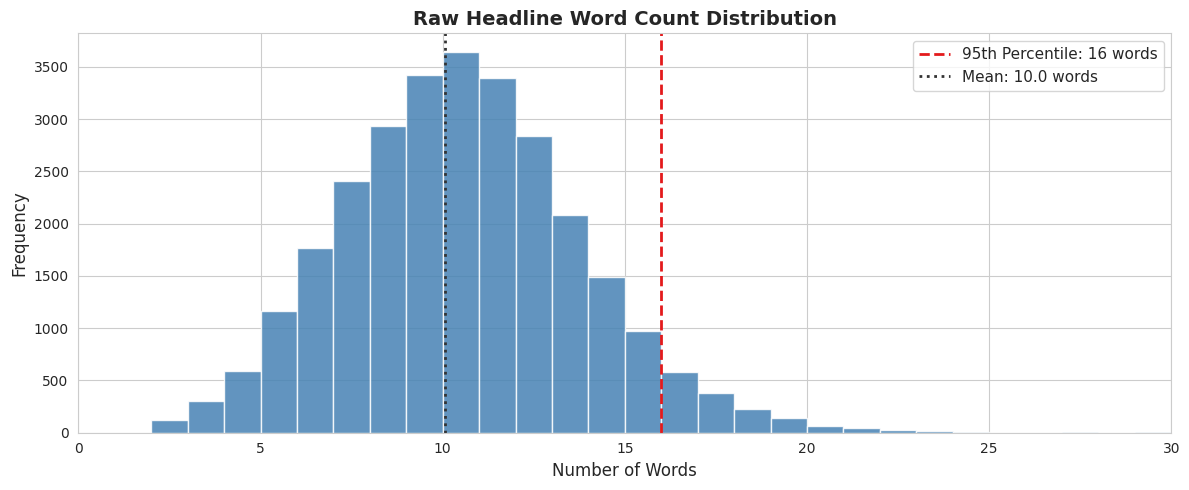

In [ ]:
# Analyse raw headline word count distribution to help choose padding length later
df['word_count'] = df['headline'].apply(lambda x: len(str(x).split()))
p95 = df['word_count'].quantile(0.95)
avg = df['word_count'].mean()

plt.figure(figsize=(12, 5))
sns.set_style("whitegrid")
plt.hist(df['word_count'], bins=range(0, 31),
         color='#4682B4', edgecolor='white', alpha=0.85)
plt.axvline(p95, color='#E31A1C', linestyle='--', linewidth=2,
            label=f'95th Percentile: {int(p95)} words')
plt.axvline(avg, color='#333333', linestyle=':', linewidth=2,
            label=f'Mean: {avg:.1f} words')
plt.xlim(0, 30)
plt.title('Raw Headline Word Count Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150)
plt.show()

## Section 2: Text Preprocessing

In [ ]:
# Text cleaning pipeline
# Steps: lowercase, expand contractions, remove urls/mentions/hashtags,
# Remove numbers and punctuation, remove stopwords, lemmatize

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_headline'] = df['headline'].apply(clean_text)

# Remove rows where cleaning produced empty string
df = df[df['clean_headline'].str.strip() != ''].reset_index(drop=True)

print(f"Dataset after cleaning: {df.shape}")
print("\nSample before and after cleaning:")
for i in range(3):
    print(f"  Original : {df['headline'].iloc[i]}")
    print(f"  Cleaned  : {df['clean_headline'].iloc[i]}")
    print()

Dataset after cleaning: (28617, 4)

Sample before and after cleaning:
  Original : thirtysomething scientists unveil doomsday clock of hair loss
  Cleaned  : thirtysomething scientist unveil doomsday clock hair loss

  Original : dem rep. totally nails why congress is falling short on gender, racial equality
  Cleaned  : dem rep totally nail congress falling short gender racial equality

  Original : eat your veggies: 9 deliciously different recipes
  Cleaned  : eat veggie deliciously different recipe



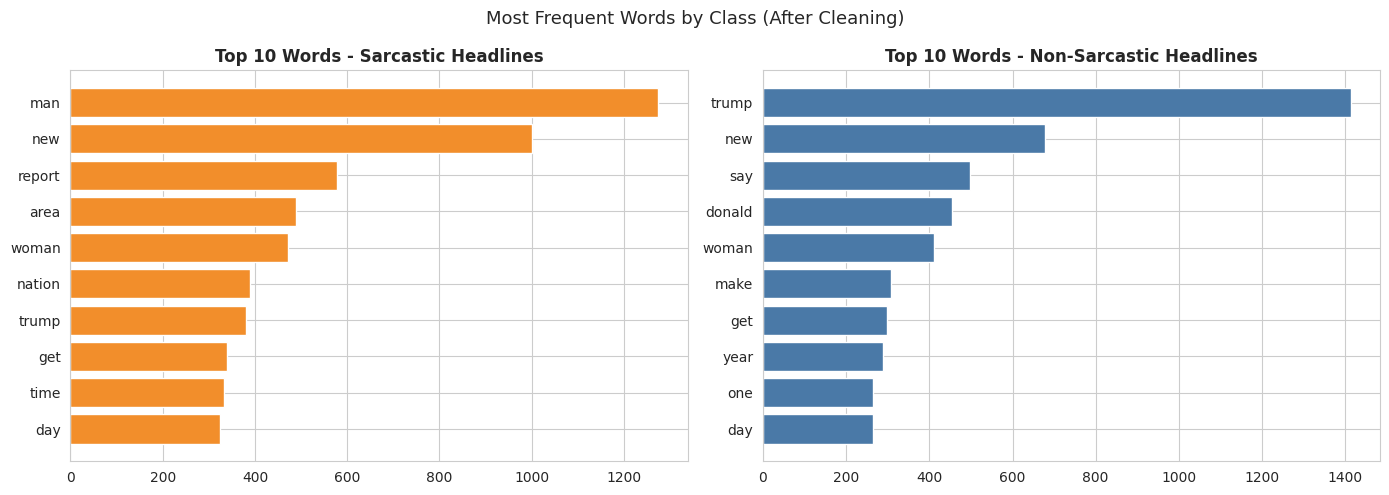

In [ ]:
# Top 10 most frequent words per class after cleaning
sarc_words     = ' '.join(df[df['is_sarcastic']==1]['clean_headline']).split()
not_sarc_words = ' '.join(df[df['is_sarcastic']==0]['clean_headline']).split()

top_sarc     = Counter(sarc_words).most_common(10)
top_not_sarc = Counter(not_sarc_words).most_common(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

words, counts = zip(*top_sarc)
axes[0].barh(words, counts, color='#F28E2B')
axes[0].set_title('Top 10 Words - Sarcastic Headlines', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

words, counts = zip(*top_not_sarc)
axes[1].barh(words, counts, color='#4A79A7')
axes[1].set_title('Top 10 Words - Non-Sarcastic Headlines', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('Most Frequent Words by Class (After Cleaning)', fontsize=13)
plt.tight_layout()
plt.savefig('top_words.png', dpi=150)
plt.show()

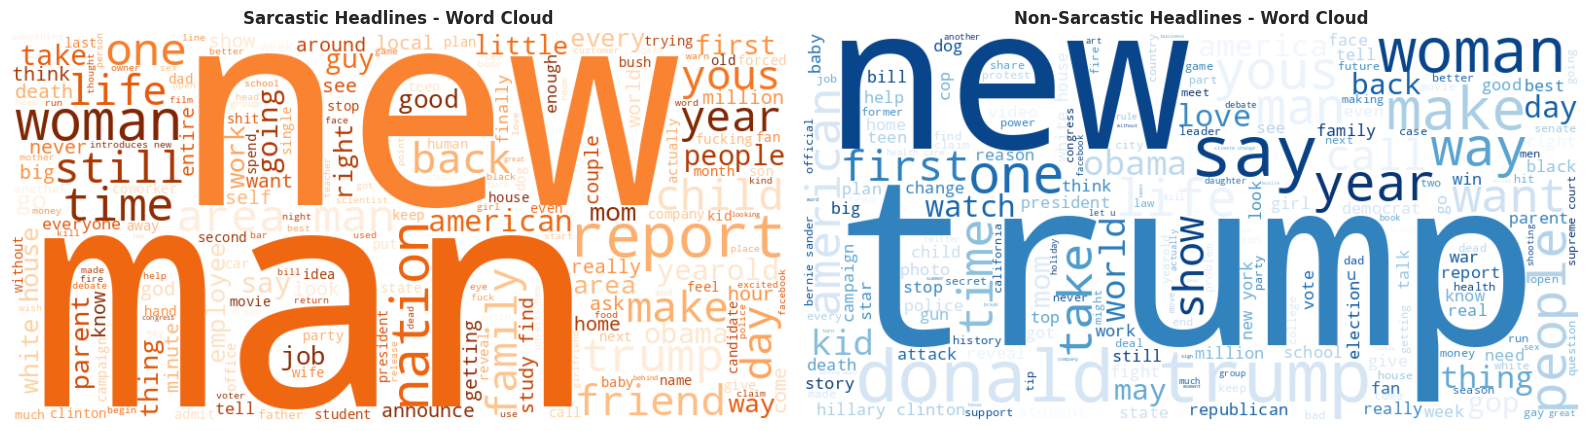

In [73]:
# Word cloud visualisation for sarcastic and non-sarcastic headlines
sarc_text     = ' '.join(df[df['is_sarcastic']==1]['clean_headline'])
not_sarc_text = ' '.join(df[df['is_sarcastic']==0]['clean_headline'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc1 = WordCloud(width=800, height=400, background_color='white',
                colormap='Oranges').generate(sarc_text)
axes[0].imshow(wc1, interpolation='bilinear')
axes[0].set_title('Sarcastic Headlines - Word Cloud', fontsize=12, fontweight='bold')
axes[0].axis('off')

wc2 = WordCloud(width=800, height=400, background_color='white',
                colormap='Blues').generate(not_sarc_text)
axes[1].imshow(wc2, interpolation='bilinear')
axes[1].set_title('Non-Sarcastic Headlines - Word Cloud', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150)
plt.show()

## Section 3: Train/Test Split, Tokenisation and Padding

In [ ]:
# Split dataset into 80% train and 20% test
# Stratify ensures both splits maintain the same class ratio
X = df['clean_headline'].values
y = df['is_sarcastic'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

y_train = np.array(y_train)
y_test  = np.array(y_test)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Train class dist : {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test class dist : {dict(zip(*np.unique(y_test,  return_counts=True)))}")

Training samples : 22893
Testing samples  : 5724
Train class dist : {np.int64(0): np.int64(11986), np.int64(1): np.int64(10907)}
Test class dist : {np.int64(0): np.int64(2997), np.int64(1): np.int64(2727)}


In [ ]:
# Tokenise text using keras tokenizer
# Vocab size = 10000 most frequent words
# Fit only on training data to avoid data leakage
VOCAB_SIZE = 10000
OOV_TOKEN  = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

word_index = tokenizer.word_index
print(f"Total unique words found: {len(word_index)}")

Total unique words found: 22505


Max length   : 106
Mean length  : 7.1
95th pct     : 11 (used as MAX_LEN)


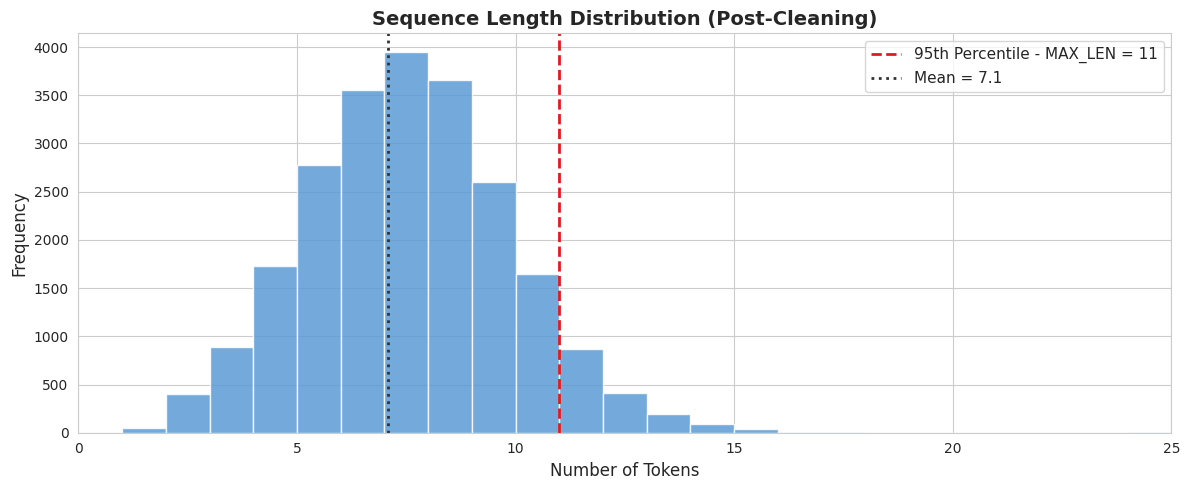


Padded train shape : (22893, 11)
Padded test  shape : (5724, 11)


In [ ]:
# Use 95th percentile of sequence lengths as max padding length
# This avoids excessively long sequences from rare outlier headlines
seq_lengths = [len(s) for s in X_train_seq]
MAX_LEN     = int(np.percentile(seq_lengths, 95))
mean_len    = np.mean(seq_lengths)

print(f"Max length   : {max(seq_lengths)}")
print(f"Mean length  : {mean_len:.1f}")
print(f"95th pct     : {MAX_LEN} (used as MAX_LEN)")

plt.figure(figsize=(12, 5))
sns.set_style("whitegrid")
ax = plt.gca()
plt.hist(seq_lengths, bins=range(0, 26),
         color='#5A9BD5', edgecolor='white', alpha=0.85)
plt.axvline(MAX_LEN, color='#E31A1C', linestyle='--', linewidth=2,
            label=f'95th Percentile - MAX_LEN = {MAX_LEN}')
plt.axvline(mean_len, color='#333333', linestyle=':', linewidth=2,
            label=f'Mean = {mean_len:.1f}')
plt.xlim(0, 25)
plt.title('Sequence Length Distribution (Post-Cleaning)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Tokens', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('sequence_lengths.png', dpi=150)
plt.show()

# Apply padding and truncation
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nPadded train shape : {X_train_pad.shape}")
print(f"Padded test  shape : {X_test_pad.shape}")

## Section 4: Global Settings and Helper Functions

In [ ]:
# Global hyperparameters used across all models
EMBEDDING_DIM = 50
EPOCHS        = 20
BATCH_SIZE    = 64

# Early stopping — monitors val loss, restores best weights
def get_early_stop():
    return EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [ ]:
# Plot training and validation loss and accuracy curves
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'],     label='Train Loss',     linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss',       linewidth=2)
    axes[0].set_title(f'{title} - Loss',      fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
    axes[1].set_title(f'{title} - Accuracy',      fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ", "_")}_curves.png', dpi=150)
    plt.show()

In [ ]:
# Print classification report and accuracy
def print_report(model, X_pad, y_true, model_name):
    y_pred_prob = model.predict(X_pad, verbose=0)
    y_pred      = (y_pred_prob > 0.5).astype('int32').flatten()
    acc         = accuracy_score(y_true, y_pred)

    print(f"\n{'='*55}")
    print(f"  {model_name} - Evaluation Results")
    print(f"{'='*55}")
    print(f"  Test Accuracy: {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=['Not Sarcastic', 'Sarcastic']))
    return acc, y_pred

In [ ]:
# Plot a large, well-styled confusion matrix
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm     = confusion_matrix(y_true, y_pred)
    total  = cm.sum()
    labels = ['Not Sarcastic', 'Sarcastic']

    fig, ax = plt.subplots(figsize=(8, 6))

    # Draw heatmap
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.5, linecolor='white', ax=ax,
                cbar_kws={'shrink': 0.8})

    # Add count and percentage inside each cell
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            count   = cm[i, j]
            percent = count / total * 100
            color   = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j + 0.5, i + 0.45, f'{count}',
                    ha='center', va='center',
                    fontsize=18, fontweight='bold', color=color)
            ax.text(j + 0.5, i + 0.62, f'({percent:.1f}%)',
                    ha='center', va='center',
                    fontsize=11, color=color)

    ax.set_title(f'Confusion Matrix - {model_name}',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
    ax.set_ylabel('True Label',      fontsize=12, labelpad=10)
    ax.tick_params(axis='both', labelsize=11)

    plt.tight_layout()
    plt.savefig(f'cm_{model_name.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

## Section 5: Load Pretrained GloVe Embeddings

In [ ]:
# Load pretrained GloVe embeddings (50 dimensional)
# GloVe-wiki-gigaword-50 is trained on Wikipedia and Gigaword which matches
# news headline vocabulary well — used for Models 3, 4 and the bonus experiment
print("Loading GloVe embeddings...")
glove_model = api.load('glove-wiki-gigaword-50')
GLOVE_DIM   = glove_model.vector_size
print(f"GloVe loaded. Embedding dimension: {GLOVE_DIM}")

Loading GloVe embeddings...
GloVe loaded. Embedding dimension: 50


In [ ]:
# Build embedding matrix from GloVe vectors
# Words not found in GloVe remain as zero vectors
vocab_size_actual = min(VOCAB_SIZE, len(word_index) + 1)
embedding_matrix  = np.zeros((vocab_size_actual, GLOVE_DIM))
found = 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in glove_model:
        embedding_matrix[idx] = glove_model[word]
        found += 1

coverage = found / min(len(word_index), VOCAB_SIZE) * 100
print(f"Words found in GloVe  : {found}")
print(f"Vocabulary coverage   : {coverage:.1f}%")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

Words found in GloVe  : 9706
Vocabulary coverage   : 97.1%
Embedding matrix shape: (10000, 50)


## Section 6: Model 1 — Simple RNN with Trainable Embedding

In [ ]:
# Build simple RNN model with a smaller trainable embedding
# Reduced embedding dim (32) and units (32) to reduce overfitting on short headlines
# Lower learning rate (0.0005) for more stable convergence
rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=32, input_length=MAX_LEN),
    SpatialDropout1D(0.4),
    SimpleRNN(32, dropout=0.3),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name='Simple_RNN')

rnn_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)
rnn_model.build(input_shape=(None, MAX_LEN))
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 11, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 323,169 (1.23 MB)

 Trainable params: 323,169 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train simple RNN model
start       = time.time()
rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[get_early_stop()],
    verbose=1
)
rnn_time = time.time() - start
print(f"Simple RNN training time: {rnn_time:.2f} seconds")

Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.5817 - loss: 0.6668 - val_accuracy: 0.6908 - val_loss: 0.5773
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7579 - loss: 0.5035 - val_accuracy: 0.7677 - val_loss: 0.4774
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8408 - loss: 0.3745 - val_accuracy: 0.7869 - val_loss: 0.4817
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8806 - loss: 0.2966 - val_accuracy: 0.7934 - val_loss: 0.4996
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9014 - loss: 0.2521 - val_accuracy: 0.7930 - val_loss: 0.5200
Simple RNN training time: 17.53 seconds


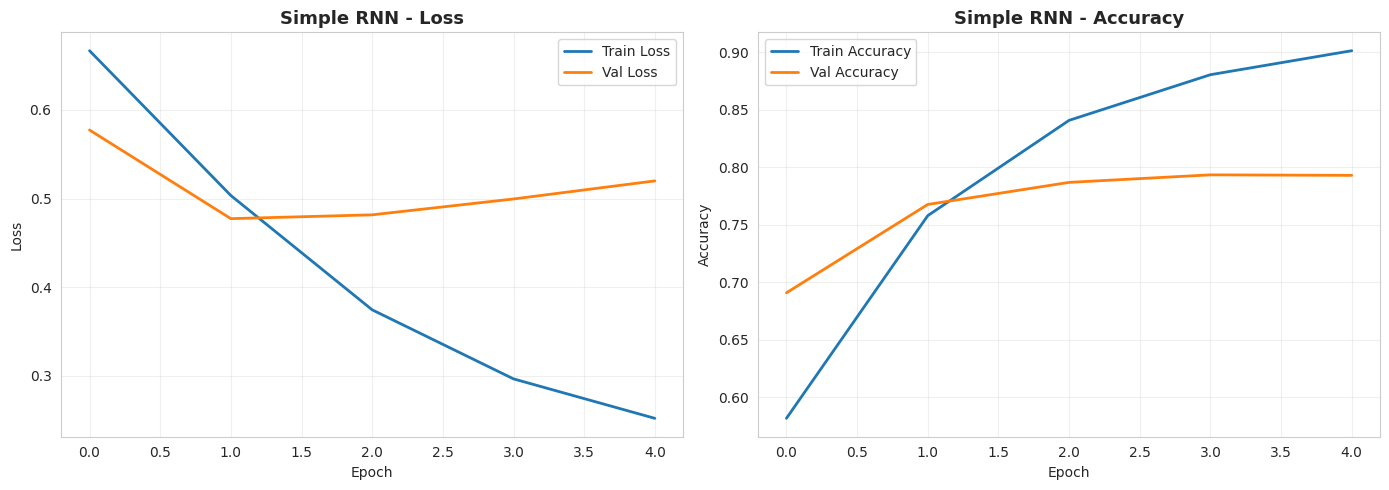

In [ ]:
# Plot training and validation curves — Simple RNN
plot_history(rnn_history, 'Simple RNN')

In [ ]:
# Classification report — Simple RNN
rnn_acc, rnn_preds = print_report(rnn_model, X_test_pad, y_test, 'Simple RNN')


  Simple RNN - Evaluation Results
  Test Accuracy: 78.07%

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.80      0.78      0.79      2997
    Sarcastic       0.76      0.78      0.77      2727

     accuracy                           0.78      5724
    macro avg       0.78      0.78      0.78      5724
 weighted avg       0.78      0.78      0.78      5724



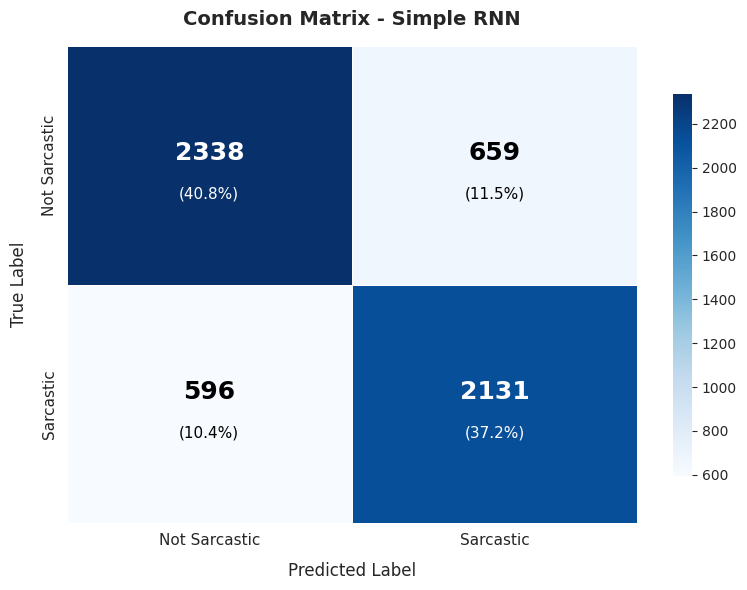

In [ ]:
# Confusion matrix — Simple RNN
plot_confusion_matrix(y_test, rnn_preds, 'Simple RNN')

## Section 7: Model 2 — LSTM with Trainable Embedding

In [ ]:
# Build lightweight LSTM model with trainable embedding
# LSTM improves over RNN by using gates to control information flow
# Smaller architecture (32 units) generalises better on short headlines
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=32, input_length=MAX_LEN),
    SpatialDropout1D(0.4),
    LSTM(32, dropout=0.2),
    Dense(16, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name='LSTM')

lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)
lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 32)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 11, 32)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,865 (1.25 MB)

 Trainable params: 328,865 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train LSTM model
start        = time.time()
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[get_early_stop()],
    verbose=1
)
lstm_time = time.time() - start
print(f"LSTM training time: {lstm_time:.2f} seconds")

Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.6826 - loss: 0.5756 - val_accuracy: 0.7838 - val_loss: 0.4565
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8302 - loss: 0.3962 - val_accuracy: 0.8000 - val_loss: 0.4400
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8661 - loss: 0.3295 - val_accuracy: 0.8013 - val_loss: 0.4753
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8861 - loss: 0.2920 - val_accuracy: 0.7926 - val_loss: 0.5034
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8984 - loss: 0.2671 - val_accuracy: 0.7926 - val_loss: 0.5686
LSTM training time: 24.41 seconds


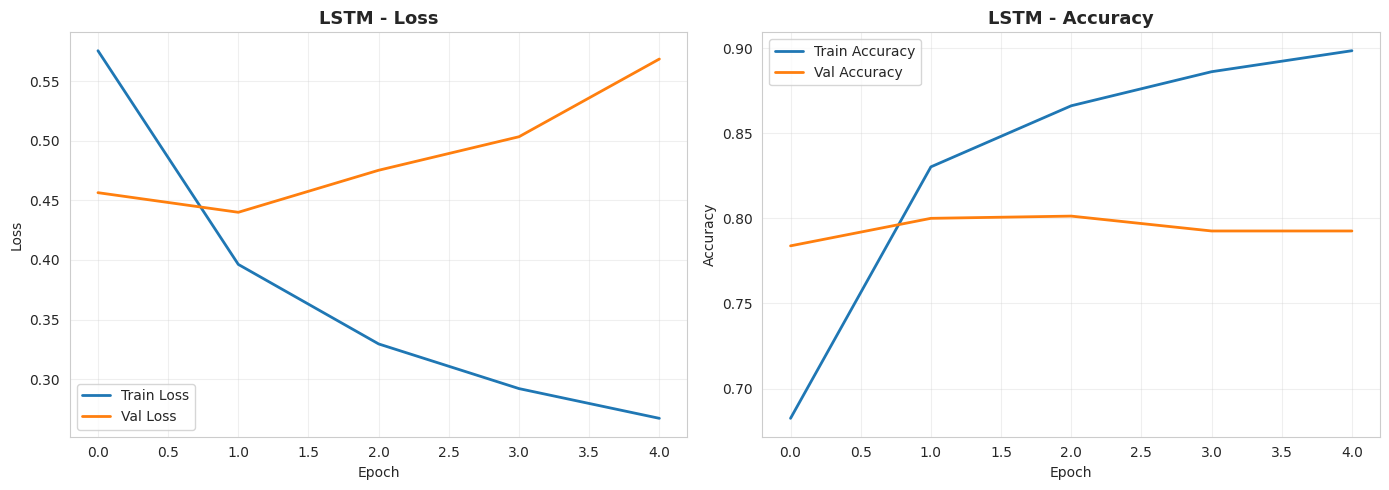

In [ ]:
# Plot training and validation curves - LSTM
plot_history(lstm_history, 'LSTM')

In [ ]:
# Classification report - LSTM
lstm_acc, lstm_preds = print_report(lstm_model, X_test_pad, y_test, 'LSTM')


  LSTM - Evaluation Results
  Test Accuracy: 78.77%

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.80      0.80      0.80      2997
    Sarcastic       0.78      0.78      0.78      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724



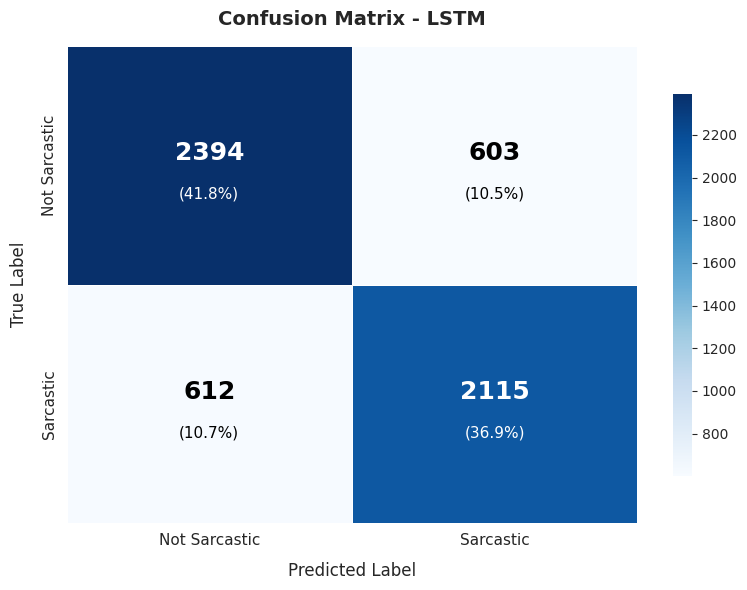

In [ ]:
# Confusion matrix - LSTM
plot_confusion_matrix(y_test, lstm_preds, 'LSTM')

## Section 8: Model 3 — LSTM with Pretrained GloVe Embeddings

In [ ]:
# Build LSTM model with frozen GloVe embeddings
# Frozen GloVe (trainable=False) provides stable pretrained word representations
# Reduces overfitting since the embedding layer does not update during training
lstm_glove_model = Sequential([
    Embedding(input_dim=vocab_size_actual, output_dim=GLOVE_DIM,
              weights=[embedding_matrix], input_length=MAX_LEN,
              trainable=False),
    SpatialDropout1D(0.3),
    LSTM(32, dropout=0.2),
    Dense(16, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
], name='LSTM_GloVe')

lstm_glove_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)
lstm_glove_model.build(input_shape=(None, MAX_LEN))
lstm_glove_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 11, 50)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        10,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,169 (1.95 MB)

 Trainable params: 11,169 (43.63 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [ ]:
# Train LSTM + GloVe model
start         = time.time()
glove_history = lstm_glove_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[get_early_stop()],
    verbose=1
)
glove_time = time.time() - start
print(f"LSTM + GloVe training time: {glove_time:.2f} seconds")

Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.6088 - loss: 0.6594 - val_accuracy: 0.6747 - val_loss: 0.6117
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6576 - loss: 0.6248 - val_accuracy: 0.6930 - val_loss: 0.5873
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6769 - loss: 0.6054 - val_accuracy: 0.7131 - val_loss: 0.5629
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6968 - loss: 0.5867 - val_accuracy: 0.7271 - val_loss: 0.5435
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7049 - loss: 0.5765 - val_accuracy: 0.7297 - val_loss: 0.5288
Epoch 6/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7115 - loss: 0.5675 - val_accuracy: 0.7367 - val_loss: 0.5205
Epoch 7/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7186 - loss: 0.5553 - val_accuracy: 0.7384 - val_loss: 0.5124
Epoch 8/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7223 - loss: 0.5518 - val_accuracy: 

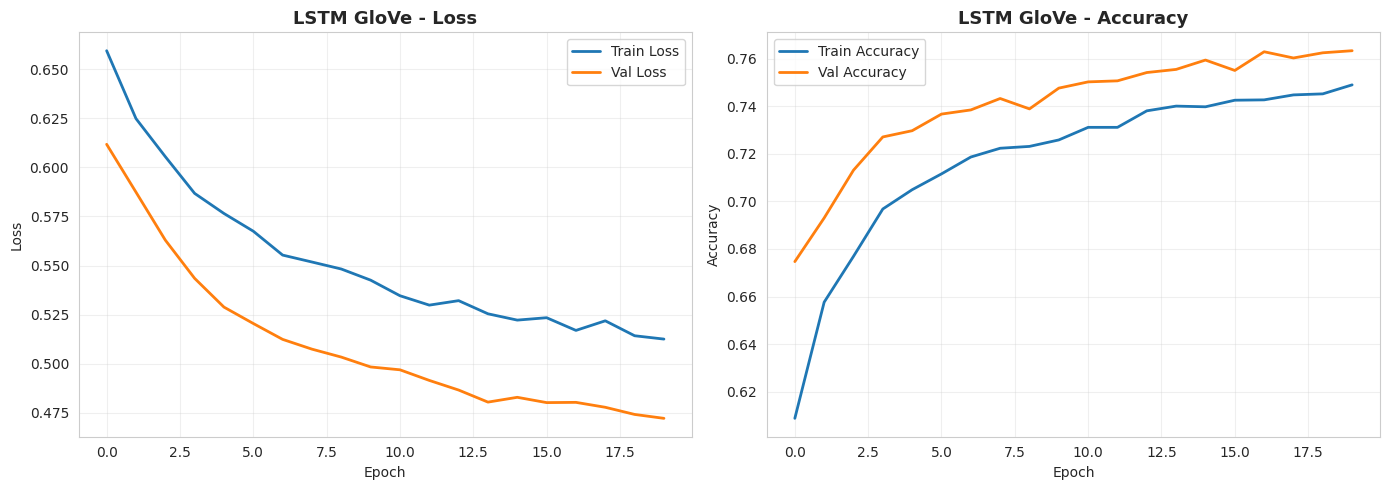

In [ ]:
# Plot training and validation curves - LSTM + GloVe
plot_history(glove_history, 'LSTM GloVe')

In [ ]:
# Classification report - LSTM + GloVe
glove_acc, glove_preds = print_report(lstm_glove_model, X_test_pad, y_test, 'LSTM GloVe')


  LSTM GloVe - Evaluation Results
  Test Accuracy: 76.96%

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.77      0.79      0.78      2997
    Sarcastic       0.77      0.74      0.75      2727

     accuracy                           0.77      5724
    macro avg       0.77      0.77      0.77      5724
 weighted avg       0.77      0.77      0.77      5724



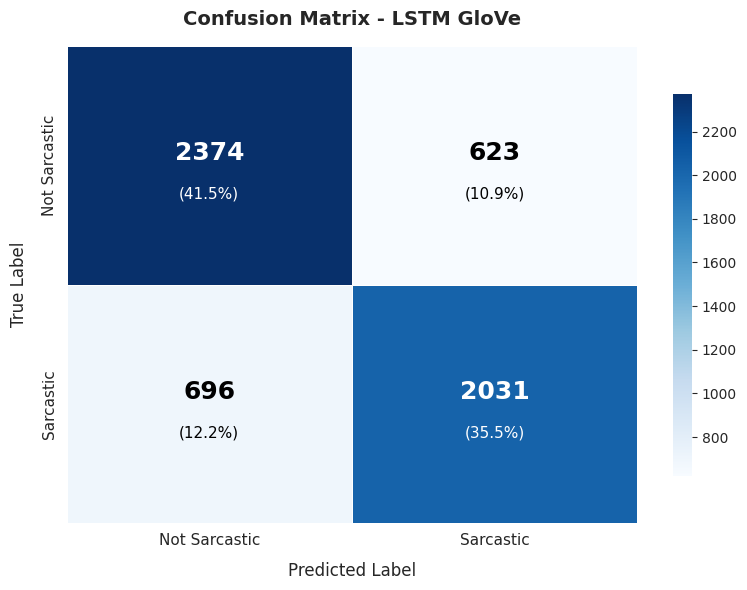

In [ ]:
# Confusion matrix - LSTM + GloVe
plot_confusion_matrix(y_test, glove_preds, 'LSTM GloVe')

## Section 9: Model 4 - Bidirectional LSTM with GloVe (Bonus)

A Bidirectional LSTM processes sequences in both forward and backward directions simultaneously. This is particularly useful for sarcasm detection since the punchline often appears at the end of a headline - reading backwards helps the model catch this pattern earlier.

In [ ]:
# Build bidirectional LSTM with frozen GloVe embeddings
# Uses same embedding matrix as Model 3 for a fair comparison
bilstm_model = Sequential([
    Embedding(input_dim=vocab_size_actual, output_dim=GLOVE_DIM,
              weights=[embedding_matrix], input_length=MAX_LEN,
              trainable=False),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, dropout=0.2)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
], name='BiLSTM_GloVe')

bilstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)
bilstm_model.build(input_shape=(None, MAX_LEN))
bilstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "BiLSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 11, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 11, 50)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        58,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 569,249 (2.17 MB)

 Trainable params: 69,249 (270.50 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [ ]:
# Train bidirectional LSTM model
start          = time.time()
bilstm_history = bilstm_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[get_early_stop()],
    verbose=1
)
bilstm_time = time.time() - start
print(f"BiLSTM + GloVe training time: {bilstm_time:.2f} seconds")

Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.6534 - loss: 0.6215 - val_accuracy: 0.7105 - val_loss: 0.5596
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6980 - loss: 0.5736 - val_accuracy: 0.7332 - val_loss: 0.5302
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7190 - loss: 0.5477 - val_accuracy: 0.7428 - val_loss: 0.5121
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7350 - loss: 0.5255 - val_accuracy: 0.7624 - val_loss: 0.4958
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7447 - loss: 0.5117 - val_accuracy: 0.7672 - val_loss: 0.4816
Epoch 6/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.7546 - loss: 0.4963 - val_accuracy: 0.7651 - val_loss: 0.4775
Epoch 7/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7629 - loss: 0.4869 - val_accuracy: 0.7773 - val_loss: 0.4700
Epoch 8/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7640 - loss: 0.4825 - val_acc

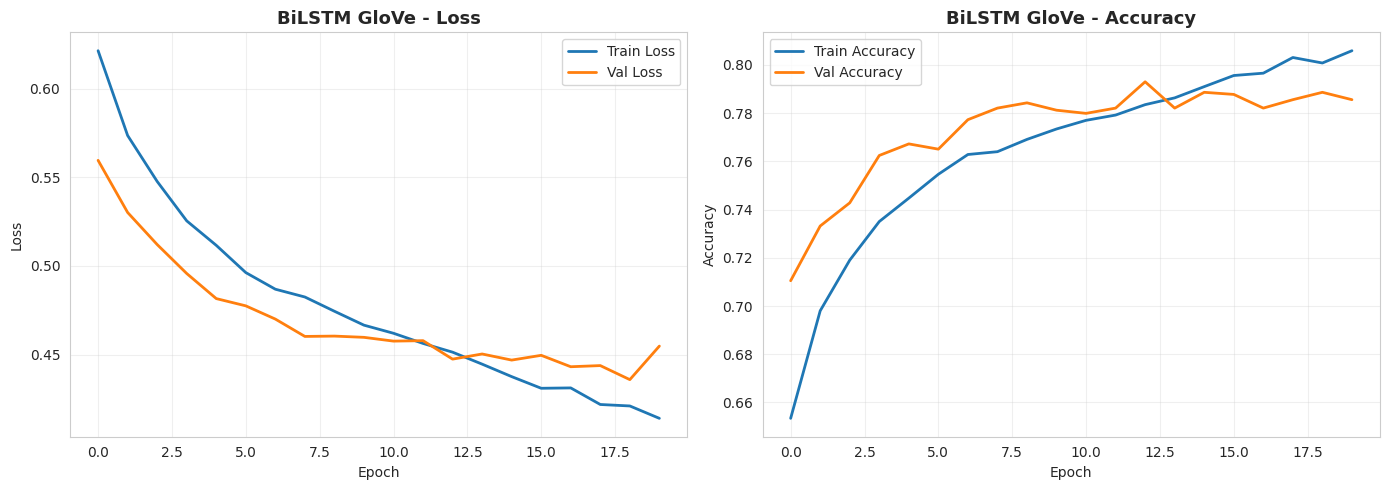

In [ ]:
# Plot training and validation curves - BiLSTM + GloVe
plot_history(bilstm_history, 'BiLSTM GloVe')

In [ ]:
# Classification report - BiLSTM + GloVe
bilstm_acc, bilstm_preds = print_report(bilstm_model, X_test_pad, y_test, 'BiLSTM GloVe')


  BiLSTM GloVe - Evaluation Results
  Test Accuracy: 79.12%

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.80      0.80      0.80      2997
    Sarcastic       0.78      0.78      0.78      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724



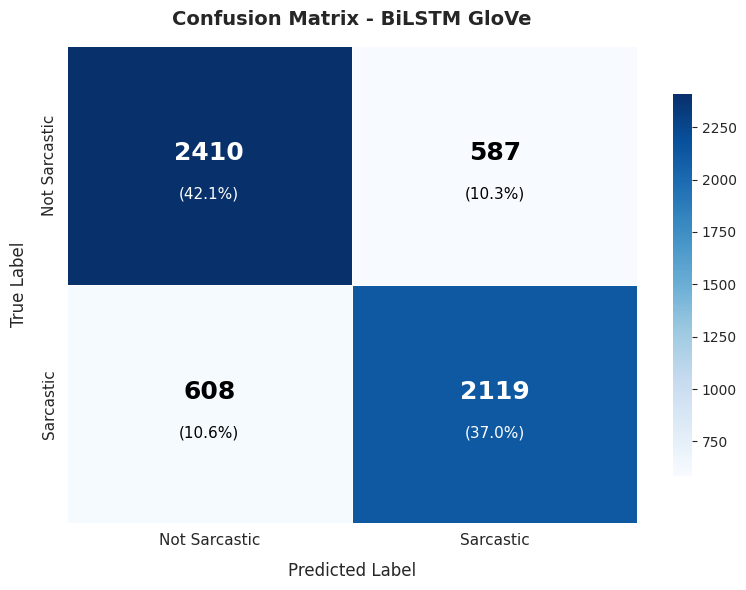

In [ ]:
# Confusion matrix - BiLSTM + GloVe
plot_confusion_matrix(y_test, bilstm_preds, 'BiLSTM GloVe')

## Section 10: Bonus Experiment

### Simple RNN with GloVe

In [ ]:
# test if GloVe also improves Simple RNN
# This helps understand whether the improvement in Models 3 and 4 was due to GloVe specifically or the LSTM architecture
rnn_glove_model = Sequential([
    Embedding(input_dim=vocab_size_actual, output_dim=GLOVE_DIM,
              weights=[embedding_matrix], input_length=MAX_LEN,
              trainable=False),
    SpatialDropout1D(0.2),
    SimpleRNN(64, dropout=0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
], name='Simple_RNN_GloVe')

rnn_glove_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)
rnn_glove_model.build(input_shape=(None, MAX_LEN))
rnn_glove_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Simple_RNN_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 11, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ (None, 11, 50)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 509,473 (1.94 MB)

 Trainable params: 9,473 (37.00 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [ ]:
# Train RNN + GloVe bonus model
start            = time.time()
rnn_glove_history = rnn_glove_model.fit(
    X_train_pad, y_train,
    epochs=15, batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[get_early_stop()],
    verbose=1
)
rnn_glove_time = time.time() - start
print(f"Simple RNN + GloVe training time: {rnn_glove_time:.2f} seconds")

Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6179 - loss: 0.6467 - val_accuracy: 0.6860 - val_loss: 0.6096
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6590 - loss: 0.6208 - val_accuracy: 0.6895 - val_loss: 0.5968
Epoch 3/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6667 - loss: 0.6125 - val_accuracy: 0.7017 - val_loss: 0.5804
Epoch 4/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6741 - loss: 0.6056 - val_accuracy: 0.6869 - val_loss: 0.5934
Epoch 5/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6763 - loss: 0.5999 - val_accuracy: 0.7188 - val_loss: 0.5697
Epoch 6/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6849 - loss: 0.5919 - val_accuracy: 0.7092 - val_loss: 0.5653
Epoch 7/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6902 - loss: 0.5888 - val_accuracy: 0.7240 - val_loss: 0.5551
Epoch 8/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6923 - loss: 0.5820 - val_accuracy: 0.

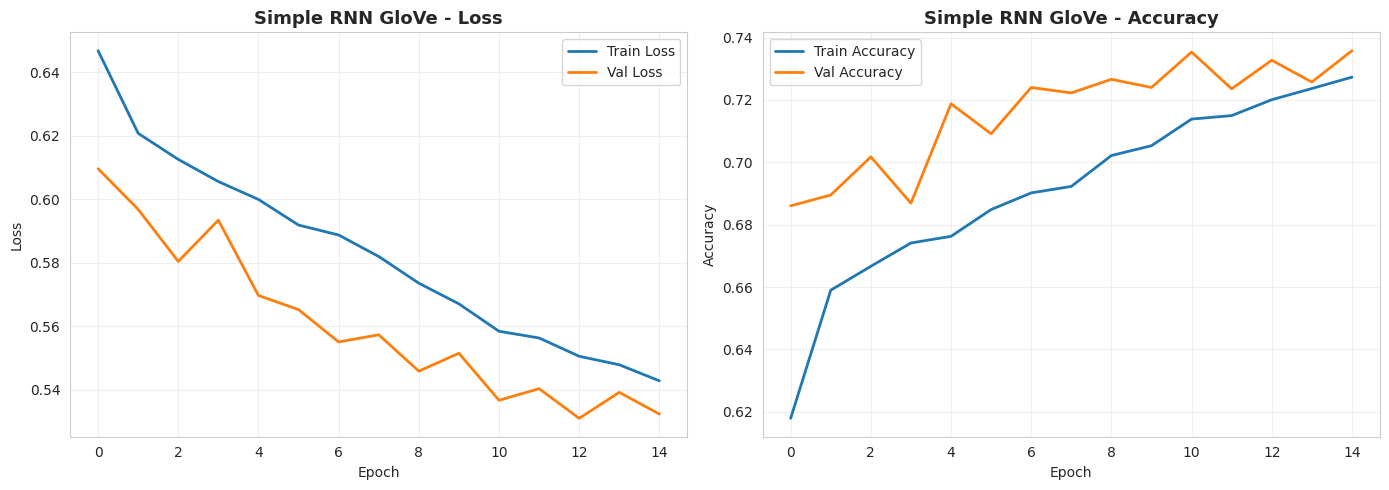

In [ ]:
# Plot training and validation curves — RNN + GloVe
plot_history(rnn_glove_history, 'Simple RNN GloVe')

In [ ]:
# Classification report - RNN + GloVe
rnn_glove_acc, rnn_glove_preds = print_report(
    rnn_glove_model, X_test_pad, y_test, 'Simple RNN GloVe')


  Simple RNN GloVe - Evaluation Results
  Test Accuracy: 73.06%

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.74      0.76      0.75      2997
    Sarcastic       0.72      0.70      0.71      2727

     accuracy                           0.73      5724
    macro avg       0.73      0.73      0.73      5724
 weighted avg       0.73      0.73      0.73      5724



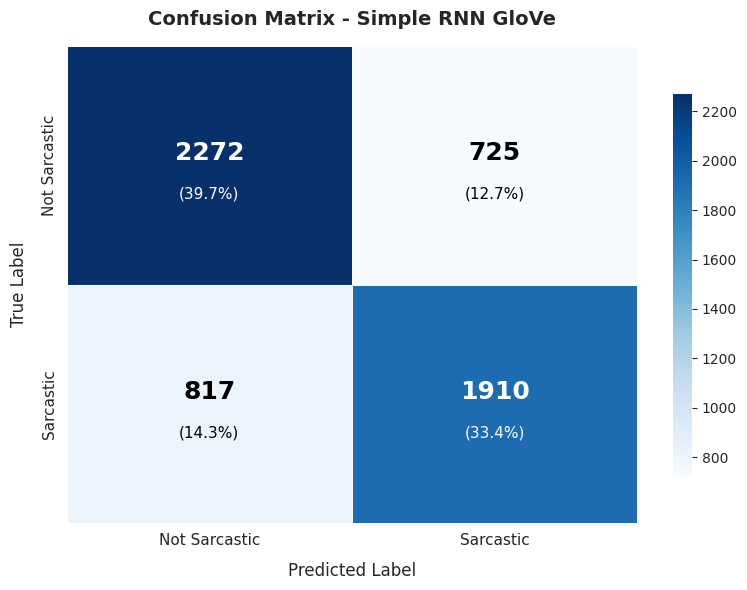

In [ ]:
# Confusion matrix - RNN + GloVe
plot_confusion_matrix(y_test, rnn_glove_preds, 'Simple RNN GloVe')

### Regularized Lightweight LSTM

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(



Training Optimized Regularized LSTM...
Epoch 1/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.6889 - loss: 0.5757 - val_accuracy: 0.7891 - val_loss: 0.4555
Epoch 2/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8309 - loss: 0.4043 - val_accuracy: 0.7908 - val_loss: 0.4478
Epoch 3/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8692 - loss: 0.3397 - val_accuracy: 0.7948 - val_loss: 0.4809
Epoch 4/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8842 - loss: 0.3016 - val_accuracy: 0.7926 - val_loss: 0.5099
Epoch 5/20
322/322 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8998 - loss: 0.2670 - val_accuracy: 0.7895 - val_loss: 0.5671


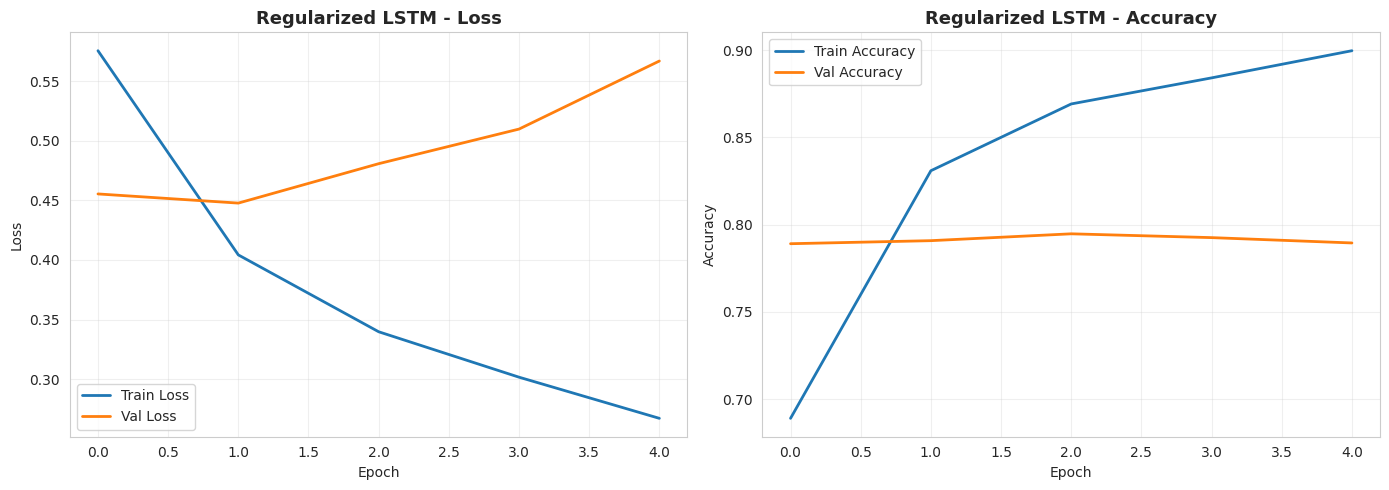


  Regularized LSTM - Evaluation Results
  Test Accuracy: 79.19%

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.79      0.82      0.80      2997
    Sarcastic       0.79      0.76      0.78      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724



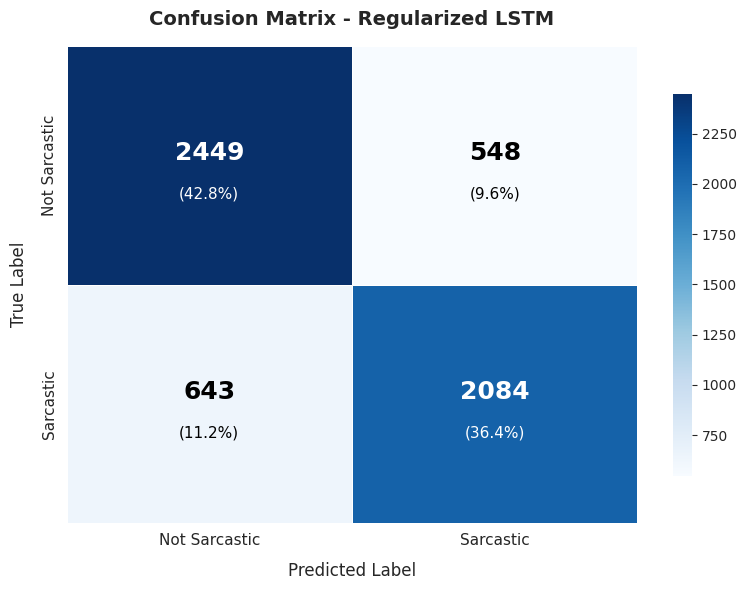

In [74]:
# 1. Build the Optimized Model
reg_lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=32, input_length=MAX_LEN),
    SpatialDropout1D(0.4),
    LSTM(32, dropout=0.2),
    Dense(16, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name='Regularized_LSTM')

reg_lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# 2. Train it
print("\nTraining Optimized Regularized LSTM...")
start_refine = time.time()
reg_lstm_history = reg_lstm_model.fit(
    X_train_pad, y_train,
    epochs=20, batch_size=64,
    validation_split=0.1,
    callbacks=[get_early_stop()],
    verbose=1
)
reg_lstm_time = time.time() - start_refine

# 3. Evaluate and Plot
plot_history(reg_lstm_history, 'Regularized LSTM')
reg_lstm_acc, reg_lstm_preds = print_report(reg_lstm_model, X_test_pad, y_test, 'Regularized LSTM')
plot_confusion_matrix(y_test, reg_lstm_preds, 'Regularized LSTM')

## Section 11: Model Comparison

In [75]:
# Summary table of all model results
model_names = ['Simple RNN', 'LSTM Baseline', 'LSTM + GloVe', 'BiLSTM + GloVe', 'RNN + GloVe', 'Regularized LSTM']
all_accs    = [rnn_acc, lstm_acc, glove_acc, bilstm_acc, rnn_glove_acc, reg_lstm_acc]
all_times   = [rnn_time, lstm_time, glove_time, bilstm_time, rnn_glove_time, reg_lstm_time]
all_preds   = [rnn_preds, lstm_preds, glove_preds, bilstm_preds, rnn_glove_preds, reg_lstm_preds]

results = pd.DataFrame({
    'Model'             : model_names,
    'Test Accuracy (%)'  : [round(a*100, 2) for a in all_accs],
    'Training Time (s)' : [round(t, 2)      for t in all_times]
})

print("\nFinal Model Comparison:")
print("=" * 55)
print(results.to_string(index=False))


Final Model Comparison:
           Model  Test Accuracy (%)  Training Time (s)
      Simple RNN              78.07              17.53
   LSTM Baseline              78.77              24.41
    LSTM + GloVe              76.96              62.45
  BiLSTM + GloVe              79.12             128.97
     RNN + GloVe              73.06              30.58
Regularized LSTM              79.19              32.80


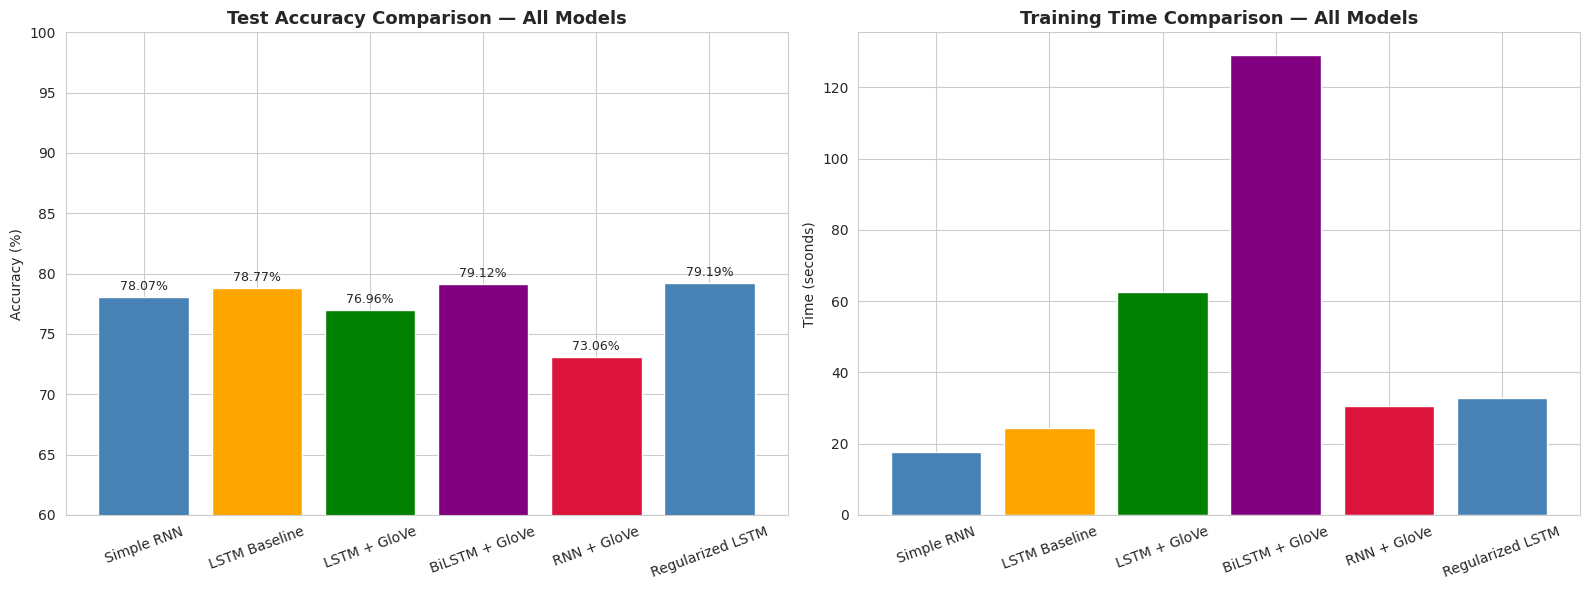

In [76]:
# Accuracy and training time comparison bar charts
colors = ['steelblue', 'orange', 'green', 'purple', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].bar(results['Model'], results['Test Accuracy (%)'], color=colors)
axes[0].set_title('Test Accuracy Comparison — All Models',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(60, 100)
axes[0].bar_label(bars, fmt='%.2f%%', padding=3, fontsize=9)
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(results['Model'], results['Training Time (s)'], color=colors)
axes[1].set_title('Training Time Comparison — All Models',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Time (seconds)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

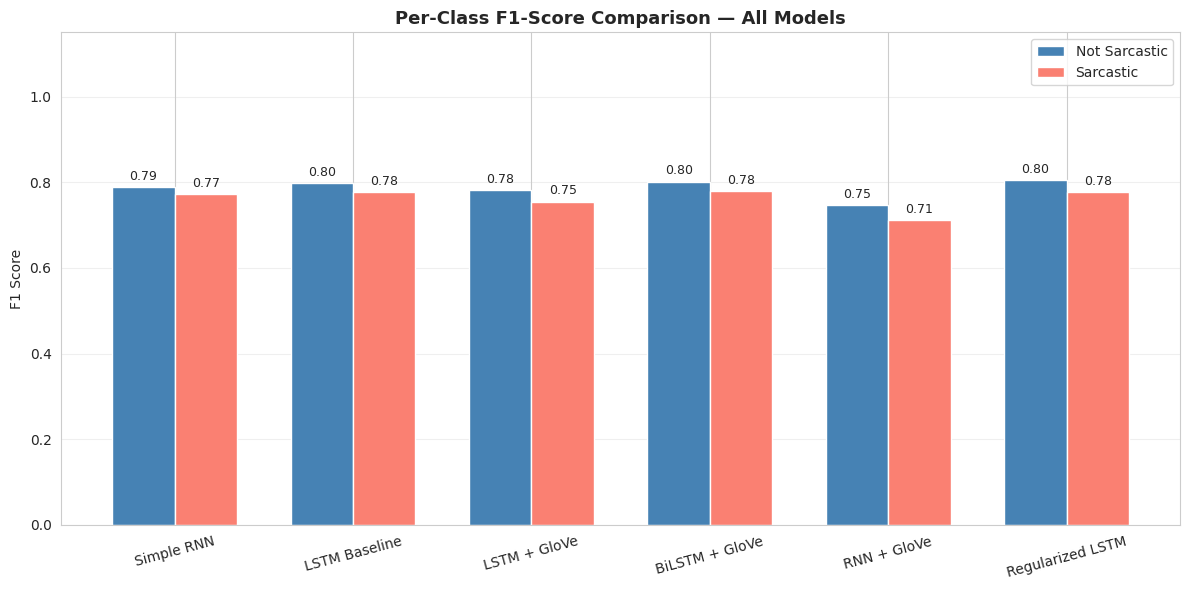

In [77]:
# Per-class F1-score comparison across all models
f1_not_sarc = [f1_score(y_test, p, pos_label=0) for p in all_preds]
f1_sarc     = [f1_score(y_test, p, pos_label=1) for p in all_preds]

x     = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
b1 = ax.bar(x - width/2, f1_not_sarc, width,
            label='Not Sarcastic', color='steelblue')
b2 = ax.bar(x + width/2, f1_sarc, width,
            label='Sarcastic', color='salmon')
ax.bar_label(b1, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.2f', padding=3, fontsize=9)
ax.set_title('Per-Class F1-Score Comparison — All Models',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=150)
plt.show()

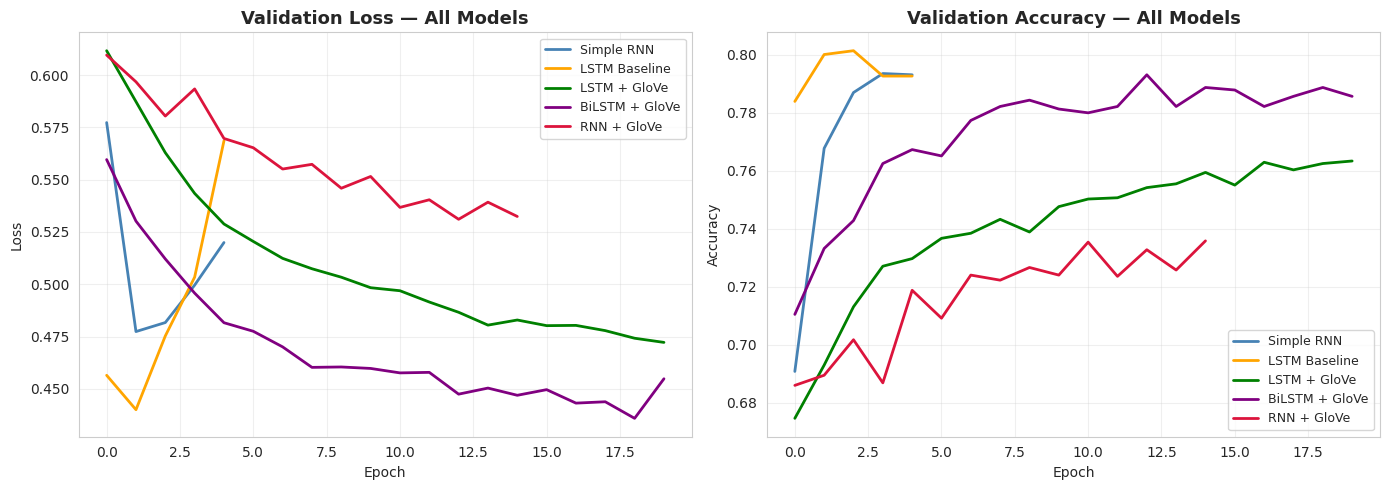

In [78]:
# Validation loss and accuracy curves for all models on one chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, name, c in zip(
    [rnn_history, lstm_history, glove_history, bilstm_history, rnn_glove_history],
    model_names, colors
):
    axes[0].plot(hist.history['val_loss'],     label=name, color=c, linewidth=2)
    axes[1].plot(hist.history['val_accuracy'], label=name, color=c, linewidth=2)

axes[0].set_title('Validation Loss — All Models',     fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Accuracy — All Models', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_val_comparison.png', dpi=150)
plt.show()

## Section 12: Error Analysis

In [79]:
# Find the best performing model for error analysis
best_entry = max(
    zip(model_names, all_preds, all_accs),
    key=lambda x: x[2]
)
best_name, best_predictions, best_acc = best_entry
print(f"Best model : {best_name}")
print(f"Accuracy   : {best_acc*100:.2f}%")

# Build dataframe of misclassified examples
error_df = pd.DataFrame({
    'Headline'  : X_test,
    'Actual'    : y_test,
    'Predicted' : best_predictions
})
misclassified = error_df[
    error_df['Actual'] != error_df['Predicted']
].reset_index(drop=True)

print(f"\nTotal misclassified : {len(misclassified)} / {len(y_test)}")
print(f"Error rate          : {len(misclassified)/len(y_test)*100:.2f}%")

Best model : Regularized LSTM
Accuracy   : 79.19%

Total misclassified : 1191 / 5724
Error rate          : 20.81%


In [80]:
# Display 5 misclassified examples for analysis in the report
print("\nMisclassified Examples:")
print("-" * 65)
for i in range(min(5, len(misclassified))):
    row    = misclassified.iloc[i]
    actual = 'Sarcastic'     if row['Actual']    == 1 else 'Not Sarcastic'
    pred   = 'Sarcastic'     if row['Predicted'] == 1 else 'Not Sarcastic'
    print(f"\nExample {i+1}:")
    print(f"  Headline  : {row['Headline']}")
    print(f"  Actual    : {actual}")
    print(f"  Predicted : {pred}")


Misclassified Examples:
-----------------------------------------------------------------

Example 1:
  Headline  : group christie campaign deserter found forest
  Actual    : Sarcastic
  Predicted : Not Sarcastic

Example 2:
  Headline  : democratic congressman protest trump environmental policy bringing endangered red wolf state union guest
  Actual    : Sarcastic
  Predicted : Not Sarcastic

Example 3:
  Headline  : neither person conversation know hedge fund
  Actual    : Sarcastic
  Predicted : Not Sarcastic

Example 4:
  Headline  : prayer answered random series event cold uncaring universe
  Actual    : Sarcastic
  Predicted : Not Sarcastic

Example 5:
  Headline  : skittish juniorsdepartment clerk call security
  Actual    : Sarcastic
  Predicted : Not Sarcastic


In [81]:
# Model complexity vs performance summary
print("\nModel Complexity vs Performance Summary")
print("=" * 60)
print(f"{'Model':<22} {'Accuracy':>10} {'Train Time':>14}")
print("-" * 60)
for name, acc, t in zip(model_names, all_accs, all_times):
    print(f"{name:<22} {acc*100:>9.2f}%  {t:>12.2f}s")


Model Complexity vs Performance Summary
Model                    Accuracy     Train Time
------------------------------------------------------------
Simple RNN                 78.07%         17.53s
LSTM Baseline              78.77%         24.41s
LSTM + GloVe               76.96%         62.45s
BiLSTM + GloVe             79.12%        128.97s
RNN + GloVe                73.06%         30.58s
Regularized LSTM           79.19%         32.80s


## Section 13: Real-Time Prediction GUI

A Gradio interface for real-time sarcasm prediction as required by the assessment brief (Section 4.5.5).

In [83]:
import gradio as gr

def predict_sarcasm(headline: str) -> str:
    if not headline.strip():
        return "Please enter a headline."

    # Apply the same cleaning pipeline used during training
    cleaned  = clean_text(headline)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(sequence, maxlen=MAX_LEN,
                             padding='post', truncating='post')

    # Use BiLSTM + GloVe as the final prediction model
    prob  = bilstm_model.predict(padded, verbose=0)[0][0]
    label = 'Sarcastic' if prob > 0.5 else 'Not Sarcastic'
    conf  = max(prob, 1 - prob) * 100
    return f"{label}  (Confidence: {conf:.1f}%)"


demo = gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.Textbox(
        label='Enter a news headline',
        lines=2,
        placeholder='e.g. Scientists discover cure for all diseases'
    ),
    outputs=gr.Textbox(label='Prediction'),
    title='Sarcasm Detector',
    description='Enter any news headline to predict whether it is sarcastic or not.',
    examples=[
        ['Scientists confirm Monday still the worst day of the week'],
        ['UN climate report warns of severe flooding risks by 2050'],
        ['Man very surprised to find out he has been asleep for 12 years'],
        ['Federal Reserve raises interest rates by 0.25 percent'],
        ['Local man becomes expert in everything after watching one YouTube video']
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ed26c64798f13b1ee8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
